In [1]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt 
import seaborn as sns

#Chamando o Arquivo do kaggle baixado.
path = r"../data/raw/kag_risk_factors_cervical_cancer.csv"


<h3><b>Checking the Data Set</h3>
<h4>Analyze the initial data, checking the table's composition only to get a first impression, without drawing any hasty conclusions or taking any action.</h4>

In [2]:
df_raw = pd.read_csv(path)
df = df_raw.copy()

#Verificando as propriedades do banco de dado Originais
print(df.shape) #Ver Linhas e Colunas
print(df.head(10)) #Verificar os 10 primeiros elementos
print(df.describe()) 
print(df.info()) #Informações da tabela

(858, 36)
   Age Number of sexual partners First sexual intercourse Num of pregnancies  \
0   18                       4.0                     15.0                1.0   
1   15                       1.0                     14.0                1.0   
2   34                       1.0                        ?                1.0   
3   52                       5.0                     16.0                4.0   
4   46                       3.0                     21.0                4.0   
5   42                       3.0                     23.0                2.0   
6   51                       3.0                     17.0                6.0   
7   26                       1.0                     26.0                3.0   
8   45                       1.0                     20.0                5.0   
9   44                       3.0                     15.0                  ?   

  Smokes Smokes (years) Smokes (packs/year) Hormonal Contraceptives  \
0    0.0            0.0               

<h3><b>Checking for empty elements<b></h3>
<h4>Checking and summing the total number of empty elements in each column, for future processing</h4>

In [3]:
valores_faltando = df.isnull().sum()
print(valores_faltando) #Não Existe valores faltando no banco de dados

Age                                   0
Number of sexual partners             0
First sexual intercourse              0
Num of pregnancies                    0
Smokes                                0
Smokes (years)                        0
Smokes (packs/year)                   0
Hormonal Contraceptives               0
Hormonal Contraceptives (years)       0
IUD                                   0
IUD (years)                           0
STDs                                  0
STDs (number)                         0
STDs:condylomatosis                   0
STDs:cervical condylomatosis          0
STDs:vaginal condylomatosis           0
STDs:vulvo-perineal condylomatosis    0
STDs:syphilis                         0
STDs:pelvic inflammatory disease      0
STDs:genital herpes                   0
STDs:molluscum contagiosum            0
STDs:AIDS                             0
STDs:HIV                              0
STDs:Hepatitis B                      0
STDs:HPV                              0


<h3><b>Checking the Question Values</h4>
<h4>Even though the table has no missing elements, upon analysis one notices a large number of question marks.</h4>

In [4]:
valores_interrogacao = (df == "?").sum()
print(valores_interrogacao) #Verificando quantos valores  "?" estão no banco de dados

Age                                     0
Number of sexual partners              26
First sexual intercourse                7
Num of pregnancies                     56
Smokes                                 13
Smokes (years)                         13
Smokes (packs/year)                    13
Hormonal Contraceptives               108
Hormonal Contraceptives (years)       108
IUD                                   117
IUD (years)                           117
STDs                                  105
STDs (number)                         105
STDs:condylomatosis                   105
STDs:cervical condylomatosis          105
STDs:vaginal condylomatosis           105
STDs:vulvo-perineal condylomatosis    105
STDs:syphilis                         105
STDs:pelvic inflammatory disease      105
STDs:genital herpes                   105
STDs:molluscum contagiosum            105
STDs:AIDS                             105
STDs:HIV                              105
STDs:Hepatitis B                  

<h4><b>Changed the Question Values for Nan

In [5]:
#Substituindo os valores "?" for Nan(Not a Number)
def changed_question_values(df):
    df = df.replace("?", np.nan)
    return df

df = changed_question_values(df_raw)
print(df.isna().mean()*100)

Age                                    0.000000
Number of sexual partners              3.030303
First sexual intercourse               0.815851
Num of pregnancies                     6.526807
Smokes                                 1.515152
Smokes (years)                         1.515152
Smokes (packs/year)                    1.515152
Hormonal Contraceptives               12.587413
Hormonal Contraceptives (years)       12.587413
IUD                                   13.636364
IUD (years)                           13.636364
STDs                                  12.237762
STDs (number)                         12.237762
STDs:condylomatosis                   12.237762
STDs:cervical condylomatosis          12.237762
STDs:vaginal condylomatosis           12.237762
STDs:vulvo-perineal condylomatosis    12.237762
STDs:syphilis                         12.237762
STDs:pelvic inflammatory disease      12.237762
STDs:genital herpes                   12.237762
STDs:molluscum contagiosum            12

<h3><b>Checking Duplicates</h4>
<h4>For a better dataset, it's necessary to remove exact duplicates, even if they are people and may have similar data. With 36 columns, it's extremely unlikely that everything is a coincidence.</h4>

In [6]:
#print(df[df.duplicated()]) #Vendo as duplicatas
#duplicatas_exatas = df.duplicated()

#display(df[duplicatas_exatas]) #Exibindo as duplicatas

def droping_duplicates(df):
    total_duplicatas = df.duplicated().sum() #Verificando o total de duplicatas (23 duplicatas encontradas)
    print(f"Numbers of Duplicates Removed {total_duplicatas}")
    df = df.drop_duplicates() #removendo as Duplicatas
    return df

df = droping_duplicates(df)

print(df.shape)

Numbers of Duplicates Removed 23
(835, 36)


<h3><b>Removing Columns and Rows with 50%+ Missing</h3>
<h4>Cleaning the dataset by removing any columns or rows that have more than 50% of their values missing. The goal is to improve data quality and ensure that subsequent analyses or models are not heavily influenced by incomplete data. Columns or rows with excessive missing values are often considered unreliable for meaningful insights, so they are discarded when the proportion of missing entries exceeds half of the total entries in that column or row</h4>

In [7]:
def remove_missing_values(df):
    limite_linhas = len(df.columns) * 0.5 #Metade dos elementos faltando na linha
    limite_coluna = len(df) * 0.5
    #print(df.shape)

    print(df.shape)

    rows_before = df.shape[0]
    coluns_before = df.shape[1]

    numbers_columns_before = len(df.columns)
    #["STDs: Time since first diagnosis","STDs: Time since last diagnosis"] REMOVIDAS
    #Deletando as Colunas com 50% mais de dados faltando
    df = df.dropna(axis=1,thresh=limite_coluna)

    #Deleta as linhas com metade dos elementos faltando
    df = df.dropna(thresh=limite_linhas)

    rows_after = df.shape[0]
    coluns_after = df.shape[1]

    print(f"Columns removed: {coluns_before - coluns_after}")
    print(f"Rows removed: {rows_before - rows_after}")

    return df

df = remove_missing_values(df)

print(df.shape)


(835, 36)
Columns removed: 2
Rows removed: 93
(742, 34)


<h3><b>Imputing Missing Data</h3>
<h4>It's necessary to insert data where it's missing to avoid influencing your data or having problems with type conflicts. I chose SimpleImputer with median to avoid outliers, where they won't be noticed, thus favoring accurate data collection. Additionally, the remaining data has greater reliability due to the previous process of removing missing columns and rows with 50%+ missing values ​​and duplicates, and it's also very good for numerical data.

It was also necessary to transform all columns into numeric values ​​because, even though the columns contained numbers, they were being represented as objects instead of floats.</h4>

In [8]:
def imput_missing_values(df):
    #Tenho apenas valores numéricos, utilizar a Mediana será mais adequado para substituir os valores faltando
    #Colunas listadas como objetos, trará problema na imputação
    #print(df.info())

    #Criação do imputer com Mediana como Objetivo
    num_imputer = SimpleImputer(strategy='median')

    #Havia muitas colunas sendo Object, traria problemas, precisei converter elas para numéricas
    #O pd.to_numeric checa se cada coluna é um número ou n, etenta converter para float 
    df_preenchido = df.apply(pd.to_numeric, errors='coerce')

    #Colunas com dados faltando
    colunas_faltando = [
        'Number of sexual partners', 'First sexual intercourse', 'Num of pregnancies', 
        'Smokes', 'Smokes (years)', 'Smokes (packs/year)', 
        'Hormonal Contraceptives', 'Hormonal Contraceptives (years)', 'IUD', 
        'IUD (years)', 'STDs', 'STDs (number)', 
        'STDs:condylomatosis', 'STDs:cervical condylomatosis', 'STDs:vaginal condylomatosis', 
        'STDs:vulvo-perineal condylomatosis', 'STDs:syphilis', 'STDs:pelvic inflammatory disease', 
        'STDs:genital herpes', 'STDs:molluscum contagiosum', 'STDs:AIDS', 
        'STDs:HIV', 'STDs:Hepatitis B', 'STDs:HPV'
    ]

    #Preencher todos os dados das colunas faltando com Mediana
    df_preenchido[colunas_faltando] = num_imputer.fit_transform(df_preenchido[colunas_faltando])

    return df_preenchido

df_preenchido = imput_missing_values(df)

print(df_preenchido.isna().sum())

Age                                   0
Number of sexual partners             0
First sexual intercourse              0
Num of pregnancies                    0
Smokes                                0
Smokes (years)                        0
Smokes (packs/year)                   0
Hormonal Contraceptives               0
Hormonal Contraceptives (years)       0
IUD                                   0
IUD (years)                           0
STDs                                  0
STDs (number)                         0
STDs:condylomatosis                   0
STDs:cervical condylomatosis          0
STDs:vaginal condylomatosis           0
STDs:vulvo-perineal condylomatosis    0
STDs:syphilis                         0
STDs:pelvic inflammatory disease      0
STDs:genital herpes                   0
STDs:molluscum contagiosum            0
STDs:AIDS                             0
STDs:HIV                              0
STDs:Hepatitis B                      0
STDs:HPV                              0


<h3><b>Checking Outliers</h3>
<h4>By checking for outliers through graphs, and analyzing them, it's noticeable that there are few. Smokers are scattered because most participants are non-smokers, but they are not an uninteresting piece of data to analyze. I chose to keep the outliers because, when considering isolated examples, they seem realistic rather than a data collection error. To avoid excluding potential patients due to age, I kept them.</h4>

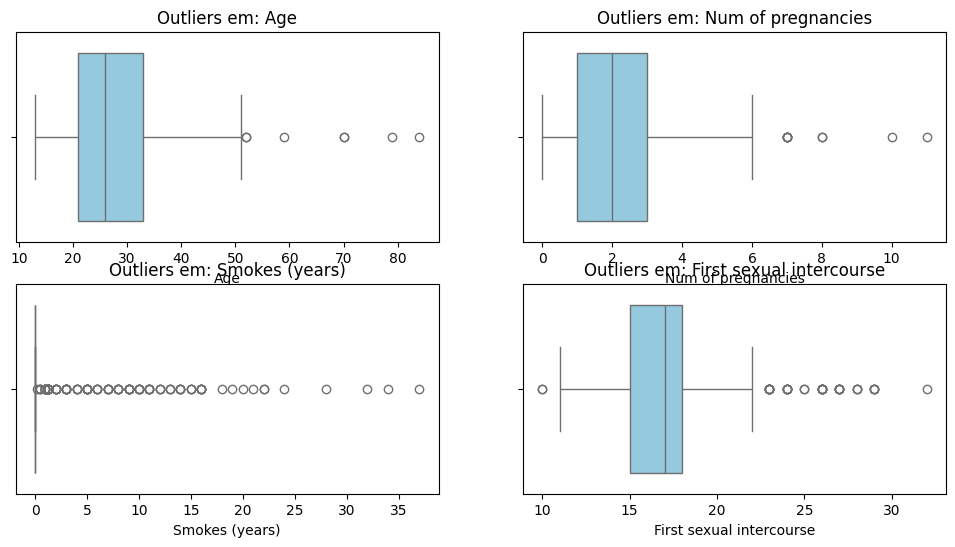

9
     Age  Number of sexual partners  First sexual intercourse  \
17    43                        3.0                      15.0   
100   34                        3.0                      15.0   
337   48                        2.0                      16.0   
480   30                        4.0                      13.0   
588   45                        5.0                      15.0   
668   84                        3.0                      20.0   
679   50                        2.0                      17.0   
682   70                        1.0                      16.0   
740   40                        1.0                      20.0   

     Num of pregnancies  Smokes  Smokes (years)  Smokes (packs/year)  \
17                  8.0     0.0             0.0             0.000000   
100                 7.0     0.0             0.0             0.000000   
337                 7.0     1.0            32.0             8.000000   
480                 8.0     0.0             0.0            

In [9]:
# Lista de colunas com dados interessantes e que podem variar muito
colunas_foco = ['Age', 'Num of pregnancies', 'Smokes (years)', 'First sexual intercourse']

# Criando os gráficos
plt.figure(figsize=(12, 6))

for i, coluna in enumerate(colunas_foco):
    plt.subplot(2, 2, i + 1) # Cria uma grade 2x2 de gráficos
    sns.boxplot(x=df_preenchido[coluna], color='skyblue')
    plt.title(f'Outliers em: {coluna}')
plt.show()
outliers_numbers_of_pregnancies = df_preenchido[df_preenchido['Num of pregnancies'] > 6]

print(len(outliers_numbers_of_pregnancies))
print(outliers_numbers_of_pregnancies)
#Manterei os outlines e utilizarei RobustScaler

<h3><b>Generating a new CSV file with the processed data</h3>
<h4>For use inside other notebooks only</h4>

In [10]:
def generation_csv_new(df_preenchido):
    df_preenchido.to_csv('../data/clean/dados_limpos.csv', index=False)
    print("New archive CSV, with data cleaning generate")

<h3>Create Pipeline</h3>
<h4>Combining all the previous processes into this pipeline</h4>

In [11]:
def pipeline_clean_date(df_raw):
    df = changed_question_values(df_raw)
    df = remove_missing_values(df)
    df = imput_missing_values(df)
    df = droping_duplicates(df)
    generation_csv_new(df)
    print(df.shape)
    return df

df = pipeline_clean_date(df_raw)

(858, 36)
Columns removed: 2
Rows removed: 98
Numbers of Duplicates Removed 19
New archive CSV, with data cleaning generate
(741, 34)
